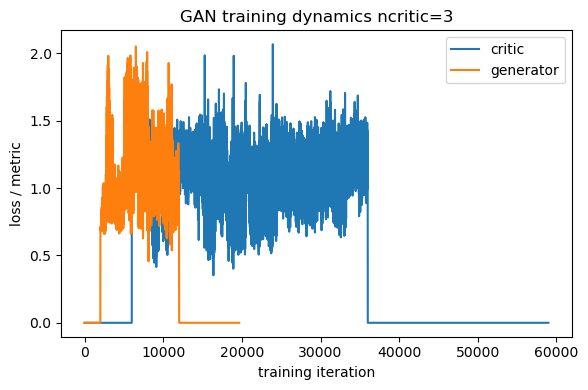

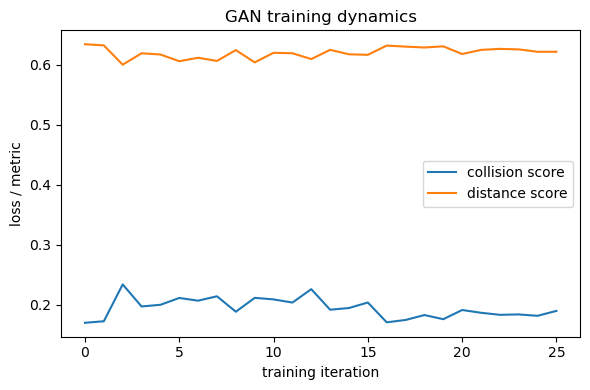

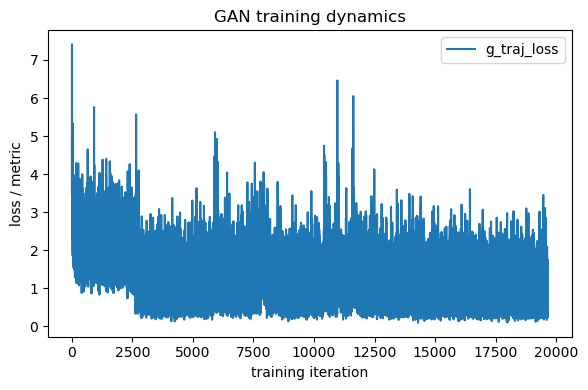

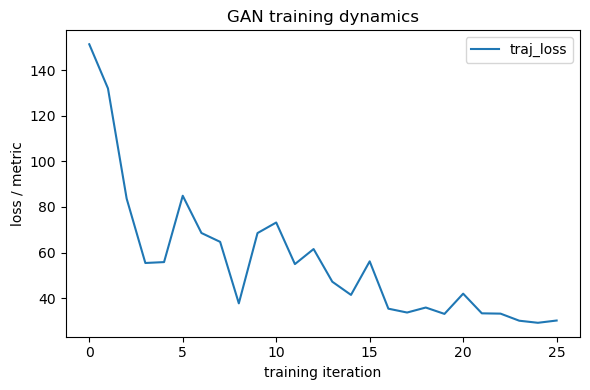

In [6]:
import numpy as np
import matplotlib.pyplot as plt
file_name = '/ibex/user/alham0a/localization_project/results/umgloc_model_kaust_dataset_map_90_3/train_history.npz'
history = dict(np.load(file_name))
plt.figure(figsize=(6,4))
plt.plot(history['d_loss'][:], label='critic')
plt.plot(history['g_loss'][:], label='generator')

plt.xlabel("training iteration")
plt.ylabel("loss / metric")
plt.title("GAN training dynamics ncritic=3")
plt.legend()
plt.tight_layout()
plt.show()


# plt.figure(figsize=(6,4))
# # plt.plot(history['g_aux_loss'], label='aux_loss')
# # plt.plot(history['g_feas_loss'], label='feas_loss')
# plt.xlabel("training iteration")
# plt.ylabel("loss / metric")
# plt.title("GAN training dynamics")
# plt.legend()
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(6,4))
plt.plot(history['cr_val'], label='collision score')
plt.plot(history['ds_val'], label='distance score')
plt.xlabel("training iteration")
plt.ylabel("loss / metric")
plt.title("GAN training dynamics")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))

# plt.plot(history['g_feas_loss'], label='g_feas_loss')
plt.plot(history['g_traj_loss'], label='g_traj_loss')
# plt.plot(history['g_loss'], label='g_loss')

# # plt.plot(history['ate_val'], label='ate_val')
plt.xlabel("training iteration")
plt.ylabel("loss / metric")
plt.title("GAN training dynamics")
plt.legend()
plt.tight_layout()
plt.show()

# plt.figure(figsize=(6,4))
# plt.plot(history['w_dist'], label='W dist')
# plt.plot(history['GP'], label='GP')
# plt.xlabel("training iteration")
# plt.ylabel("loss / metric")
# plt.title("GAN training dynamics ncritic=3")
# plt.legend()
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(6,4))
# plt.plot(history['ate_val'], label='ate')
# plt.plot(history['fde_val'], label='fde')
plt.plot(history['traj_loss_eval'], label='traj_loss')
plt.xlabel("training iteration")
plt.ylabel("loss / metric")
plt.title("GAN training dynamics")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
import torch
import torch.nn as nn

# Define the path to your .pt file
model_path = '/ibex/user/alham0a/localization_project/results/umgloc_model_kaust_dataset_map_90_1/checkpoints/gan_checkpoint_ph2_85.pt'

# Load the entire model
# Model class must be defined somewhere or in the scope where this code runs
try:
    model = torch.load(model_path)
    # Print the model structure
    print(model['g_optim_state'])
    # for key, value in model['g_optim_state'].items():
    #     print(f"Layer Name: {key} | Parameter Shape: {value.shape}")
    # Set to evaluation mode if you plan to run inference
    model.eval() 
except Exception as e:
    print(f"Could not load the entire model. Error: {e}")
    print("It is likely only the state_dict (parameters) was saved. Proceed to Scenario 2.")

{'state': {0: {'step': tensor(15289.), 'exp_avg': tensor(0.0693, device='cuda:0'), 'exp_avg_sq': tensor(0.0288, device='cuda:0')}, 1: {'step': tensor(15289.), 'exp_avg': tensor(0.2267, device='cuda:0'), 'exp_avg_sq': tensor(0.0960, device='cuda:0')}, 2: {'step': tensor(15289.), 'exp_avg': tensor([[-7.2579e-03, -3.5441e-03, -3.0083e-03,  ..., -3.4677e-03,
         -1.5676e-02,  7.5075e-03],
        [-2.3889e-02, -1.3480e-02, -2.0414e-02,  ..., -1.4181e-02,
         -2.9470e-02,  2.1979e-02],
        [ 1.9849e-05,  1.0943e-03,  1.4446e-03,  ...,  6.3818e-03,
          2.2894e-03, -3.5266e-03],
        ...,
        [-6.9834e-03, -1.2506e-02, -1.9948e-02,  ..., -1.3267e-02,
          3.3870e-03,  1.0850e-02],
        [-3.9916e-03, -5.4123e-03, -2.4050e-03,  ..., -3.6318e-03,
         -1.2924e-02,  3.2672e-03],
        [-2.5222e-02, -1.4648e-02, -2.1700e-02,  ..., -1.6343e-02,
         -2.9957e-02,  2.2950e-02]], device='cuda:0'), 'exp_avg_sq': tensor([[0.0012, 0.0004, 0.0014,  ..., 0.0007,

In [4]:
class CrossAttentionEncoderImuMask(nn.Module):  # Quantiles as Images
    def __init__(self, input_channel, args):
        super(CrossAttentionEncoderImuMask, self).__init__()
        self.context_feature_dim = args.context_feature_dim 
        self.kernel_size = args.kernel_size
        self.map_size = args.map_size
        self.imu_hidden_dim = args.imu_hidden_dim
        self.batch_size = args.batch_size
        self.num_heads = 4
        self.embed_dim = 128 # self.context_feature_dim * int(self.map_size/4) * int(self.map_size/4)
        self.head_dim = self.embed_dim // self.num_heads

        # ---------------------------------------  in __init__  -----------------------
        # self.attn_logits = None        # to store last batch for inspection
        # self.attn_probs  = None

        # Transform IMU features into Query
        #self.imu_mlp = nn.Linear(self.imu_hidden_dim, self.embed_dim)
        self.imu_mlp = nn.Sequential(
        nn.Linear(self.imu_hidden_dim, self.embed_dim),
        nn.LayerNorm(self.embed_dim),
        nn.Dropout(0.1),          # 10 % keep-out
        nn.ReLU(inplace=True))

        self.q_scale = nn.Parameter(torch.tensor(1.0))
        F = (self.map_size // 4) ** 2        # number of spatial tokens
        self.logit_bias = nn.Parameter(torch.zeros(self.num_heads, 1, F))
        nn.init.normal_(self.logit_bias, std=0.02)
    
        # self.logit_bias = nn.Parameter(torch.zeros(self.num_heads, 1, 1))  # (H,1,1)
        #self.map_mlp = nn.Linear(1, self.embed_dim)
        # CNN for spatial feature extraction (Key, Value)
        self.context_cnn = nn.Sequential(
            nn.Conv2d(input_channel, 32, kernel_size=self.kernel_size, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=self.kernel_size, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 64, kernel_size=self.kernel_size, padding=1, groups=64),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, self.context_feature_dim, kernel_size=1),
            nn.ReLU(inplace=True))#,
            #nn.Flatten())
        # Cross-Attention
        self.map_mlp = nn.Linear(self.context_feature_dim + 2, self.embed_dim)
        self.k_scale = nn.Parameter(torch.tensor(1.0))
    
        #self.cross_attention = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=4, batch_first=True)
        self.cross_attention = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=4, batch_first=True)
        # self.cross_attention.register_forward_pre_hook(
        #     self._inject_bias_as_mask
        # )
        # self.tracker = AttnTracker()
        # self.cross_attention.register_forward_hook(self._save_logits)

    def forward(self, imu_lstm_features, feasible_mask, t):
        B, _, H, W = feasible_mask.shape
        H4 = W4 = H // 4
        F_tokens = H4 * W4
        # Extract spatial features (Key, Value)
        spatial_features = self.context_cnn(feasible_mask)  # Shape: [batch_size, flattened_dim]
        spatial_features = spatial_features.permute(0, 2, 3, 1)   # [B, 32, 32, 16]
        spatial_features = spatial_features.reshape(B, int(self.map_size/4) * int(self.map_size/4), self.context_feature_dim)        # [B, F, C]

        device = spatial_features.device

        y, x = torch.meshgrid(
        torch.linspace(-1, 1, H4, device=device),
        torch.linspace(-1, 1, W4, device=device),
        indexing='ij')                           # ij = (row,col) order
        pos = torch.stack((x, y), dim=-1)            # [H4, W4, 2]
        pos = pos.view(1, F_tokens, 2)                   # [1, F, 2]
        pos    = pos.expand(B, -1, -1)      # [B, F, 2]
        spatial_features = torch.cat([spatial_features, pos], dim=-1)  # [B, F, C+2]
        
        spatial_embed = self.map_mlp(spatial_features)
        spatial_embed = F.layer_norm(spatial_embed, spatial_embed.shape[-1:])
        spatial_embed = spatial_embed * self.k_scale                  # learnable temperature

        query = self.imu_mlp(imu_lstm_features.mean(dim=1))#.unsqueeze(1)  # Shape: [1, batch_size, feature_dim]
        query = query * self.q_scale
        query = query.unsqueeze(1)  
        
        #spatial_features = spatial_features.unsqueeze(-1)  # Shape: [1, batch_size, feature_dim]
        attn_mask = (feasible_mask < 0.1).float()
        attn_mask = F.max_pool2d(attn_mask, 2, 2)             # H/2 × W/2
        attn_mask = F.max_pool2d(attn_mask, 2, 2)             # H/4 × W/4
        attn_mask_bin = attn_mask.view(B, -1).bool()              # [B, F]  → bool mask
        bias = self.logit_bias            # (H,1,F)
        bias = bias.expand(B, -1, -1, -1) # [B,H,1,F]
        bias = bias.reshape(B*self.num_heads, 1, F_tokens)  # (B·H,1,F)
        

        #att_mask = att_mask.view(self.batch_size, -1)
        # Transform IMU features into Query
        # query = query * 2.0
        #self.context_feature_dim += 2     # update once in __init__

        

        # key_norm_std = spatial_embed.norm(dim=-1).std(dim=-1).mean().item()
        # key_feat_std = spatial_embed.std(dim=1).mean().item()   # variance across F
        # print(f"std ∥kᵢ∥ across keys ≈ {key_norm_std:.4f}")
        # print(f"mean feature std across keys ≈ {key_feat_std:.4f}")
        # spatial_embed = spatial_embed * 10.0    # try 5–10 first; tweak later
        
        ######spatial_embed = spatial_embed.permute(1, 0, 2)
        # Apply cross-attention
        attn_output, attn_w = self.cross_attention(query, spatial_embed, spatial_embed, key_padding_mask=attn_mask_bin, average_attn_weights=False)
        attn_output = attn_output.squeeze(1)

        attn_w = attn_w + self.logit_bias.unsqueeze(0)            # broadcast (1,H,1,1)
        attn_w = attn_w.softmax(dim=-1)
        # var_soft = self.attn_probs.var(dim=-1).mean().item()
        # std_log  = self.attn_logits.std().item()
        # print(f"var(softmax)={var_soft:.4e}   std(logits)={std_log:.3f}")

        # row_std = self.attn_logits.std(dim=-1)        # std per row
        # row_var = self.attn_probs.var(dim=-1)         # var per row
        # print("mean row-std(logits):", row_std.mean().item())
        # print("mean row-var(softmax):", row_var.mean().item())

        # # pick first sample, head 0 (adapt if multi-head debug needed)
        # mask = ~attn_mask_bin[0]                         # shape [F]
        # free_logits = self.attn_logits[0, 0, 0, mask]    # (src_len_free,)
        
        # print("std logits (free cells only):", free_logits.std().item())
        # print("var softmax (free cells only):",
        #       self.attn_probs[0, 0, mask].var().item())

        # examine ONE head, ONE query row, ONLY free cells
        # head  = 1
        # row   = 0
        # mask  = ~attn_mask_bin[0]                       # free cells bool mask  (F,)
        # free_logits = self.attn_logits[0, head, row, mask]   # (N_free,)
        
        # print("min/max logits in free cells:", free_logits.min().item(),
        #                                      free_logits.max().item())
        # print("pairwise max │max-min│:", (free_logits.max() - free_logits.min()).item())
        # if t > 0 and t % 20 == 0:
        #     print("‖q‖ :", summary(self.q.norm(dim=-1)))          # (B,H,Lq)
        #     print("‖k‖ :", summary(self.k.norm(dim=-1)))          # (B,H,Lk)
        #     print("logits:", summary(self.logits))
        #     print("probs :", summary(self.probs))
        #     row_std = self.logits.std(-1).mean().item()       # avg σ over rows
        #     print("row-wise logit σ:", row_std)        # expect ≈ 0.3-0.4 now
    
            # B, H, Lq, Lk = self.logits.shape
            # F_side = int(Lk**0.5)            # 32 when F = 1024
            
            # # 1️⃣ histogram of logits
            # plt.figure(); plt.hist(self.logits.flatten(), bins=100)
            # plt.title("Distribution of dot-product logits"); plt.show()
            
            # # 2️⃣ histogram of probas
            # plt.figure(); plt.hist(self.probs.flatten(), bins=100)
            # plt.title("Distribution of soft-max probabilities"); plt.show()
            
            # # 3️⃣ heat-map of a single head (batch 0, head 0)
            # plt.figure(figsize=(4,4))
            # plt.imshow(self.probs[0,0,0].view(F_side, F_side),
            #            origin='lower', interpolation='nearest')
            # plt.colorbar(); plt.title("Attention map – B0 H0"); plt.show()
            

        return attn_output, attn_mask, attn_w

    # def _inject_bias_as_mask(self, module, args):
    #     """
    #     Args
    #     ----
    #     module : the MultiheadAttention instance
    #     args   : tuple(query, key, value, attn_mask, key_padding_mask, ...)
    #     Returns
    #     -------
    #     new_args : tuple(...)  with additive bias merged into attn_mask
    #     """
    #     query, key, value, *rest = args
    #     B = query.size(0)                # current batch
    #     F = key.size(1)                  # num. spatial tokens

    #     # (H,1,F) → (B·H, 1, F)   matches the batched-mask shape that
    #     # PyTorch expects when batch_first=True
    #     bias_mask = self.logit_bias      # param, already on device
    #     bias_mask = bias_mask.expand(B, -1, -1, -1)      # [B,H,1,F]
    #     bias_mask = bias_mask.reshape(B * self.num_heads, 1, F)

    #     # existing attn_mask (could be None)
    #     if rest and rest[0] is not None:
    #         attn_mask = rest[0]
    #         # broadcast existing mask if needed then add
    #         attn_mask = attn_mask + bias_mask
    #     else:
    #         attn_mask = bias_mask

    #     # rebuild the *args tuple*
    #     new_args = (query, key, value, attn_mask, *rest[1:])
    #     return new_args
        
    def _save_logits(self, module, inp, out):
        self.probs = out[1].detach()

        # reconstruct logits (pre‑softmax)
        if module._qkv_same_embed_dim:
            Wq, Wk, _ = module.in_proj_weight.chunk(3, dim=0)
            bq, bk, _ = module.in_proj_bias.chunk(3)
        else:
            Wq, bq = module.q_proj_weight, module.q_proj_bias
            Wk, bk = module.k_proj_weight, module.k_proj_bias

        query, key = inp[0], inp[1]  # (B,1,D) & (B,F,D)
        dk = module.head_dim ** 0.5
        q = F.linear(query, Wq, bq) / dk
        k = F.linear(key, Wk, bk)
        B, Lq, _ = q.shape
        self.q = q.view(B, module.num_heads, Lq, module.head_dim)
        self.k = k.view(B, module.num_heads, key.shape[1], module.head_dim)
        logits = torch.einsum('bhtd,bhsd->bhts', self.q, self.k)
        self.logits = logits.detach()

class TrajectoryGeneratorDecoder_2(nn.Module):
    def __init__(self, args):
        """
        :param input_dim: Dimensionality of the input (e.g., 2 for 2D positions).
        :param hidden_dim: Hidden size of the LSTM layer.
        :param latent_dim: Size of the latent vector for stochasticity.
        :param output_dim: Output size (2 for x, y coordinates).
        :param num_layers: Number of LSTM layers.
        """
        super(TrajectoryGeneratorDecoder_2, self).__init__()
        self.decoder_hidden_dim = args.decoder_hidden_dim
        self.output_dim = args.output_dim
        self.decoder_layers = args.decoder_layers
        self.embedding_dim = args.embedding_dim
        #self.h_dim = args.imu_hidden_dim # (simple, convlstm, attention) encoder
        self.h_dim = 6 #((CrossAttentionImuMask) Encoder)
        # LSTM cell for step-by-step prediction
        # IMU features as input
        #self.embedding = nn.Linear(self.h_dim, self.embedding_dim)
        self.embedding = nn.Sequential(
        nn.Linear(self.h_dim, self.embedding_dim),
        nn.LayerNorm(self.embedding_dim),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.1)
        )
        # encoder attention as input
        self.lstm = nn.LSTM(self.embedding_dim, self.decoder_hidden_dim, self.decoder_layers, batch_first=True)
        # Output layer to generate 2D coordinates
        self.output_layer = nn.Linear(self.decoder_hidden_dim, self.output_dim)
        self.relu = torch.nn.ReLU()
    
    def forward(self, feature_vec, state_tuple):
        """
        :param initial_position: Initial position of shape [N, 2] (x, y coordinates).
        :param encoder_hidden: Hidden state features from the ConvLSTM encoder [N, hidden_dim].
        :param latent_vector: Latent vector for initialization [N, latent_dim].
        :param seq_length: The length of the sequence to generate (number of time steps).
        :return: Generated trajectory of shape [N, seq_length, 2].
        """
        # Step 2: Prepare input position and container for generated trajectory
        decoder_input = self.embedding(feature_vec)
        decoder_input = self.relu(decoder_input)
        output, state_tuple = self.lstm(decoder_input, state_tuple)
        relative_position = self.output_layer(output)
        return relative_position


class Generator(nn.Module):
    def __init__(self, input_channel, dts, args):
        super(Generator, self).__init__()
        self.imu_hidden_dim = args.imu_hidden_dim
        self.map_size = args.map_size
        self.latent_dim = args.latent_dim
        self.decoder_hidden_dim = args.decoder_hidden_dim
        self.batch_size = args.batch_size
        self.mlp_dim = args.mlp_dim
        self.context_feature_dim = args.context_feature_dim
        self.dts = dts
        self.target_type = args.target_type
        self.embed_dim = 128

        # Encoder: ConvLSTM for spatio-temporal feature extraction
        #self.encoder = TrajectoryGeneratorEncoder(input_channel, args)
        #self.encoder  = SimpleEncoder(input_channel, args)
        self.encoder = CrossAttentionEncoderImuMask(input_channel, args)
        #self.encoder = AttentionEncoder(input_channel, args)

        #mlp_decoder_context_dims = [self.context_feature_dim*int(self.map_size/4)*int(self.map_size/4), self.mlp_dim, self.decoder_hidden_dim - self.latent_dim]  # (CrossAttentionImuMask) encoder
        #mlp_decoder_context_dims = [self.decoder_hidden_dim, self.mlp_dim, self.decoder_hidden_dim - self.latent_dim] # (simple, attention) encoder
        #mlp_decoder_context_dims = [self.imu_hidden_dim*int(self.map_size/4)*int(self.map_size/4), self.mlp_dim, self.decoder_hidden_dim - self.latent_dim]  # (convlstm) encoder

        mlp_decoder_context_dims = [self.embed_dim, self.mlp_dim, self.decoder_hidden_dim - self.latent_dim]  # (CrossAttentionImuMask) encoder

        self.mlp_decoder_context = make_mlp(mlp_decoder_context_dims)


        # Decoder full trajectory prediction
        self.decoder = TrajectoryGeneratorDecoder_2(args)

    def get_masks(self, X_quantiles, Y_quantiles, map_mask, initial_position, bounds):
        X_quantiles = relative_to_abs(X_quantiles, initial_position[:, [0]], self.dts, self.target_type)
        Y_quantiles = relative_to_abs(Y_quantiles, initial_position[:, [1]], self.dts, self.target_type)
        lower_x, lower_y = X_quantiles[:, :, 0], Y_quantiles[:, :, 0]
        upper_x, upper_y = X_quantiles[:, :, -1], Y_quantiles[:, :, -1]
        x_min, x_max, y_min, y_max = bounds

        # Method 1 without interpolation
        # Create a grid of all possible indices in the x and y dimensions
        x_full_range = torch.linspace(x_min, x_max, self.map_size, device=DEVICE)
        y_full_range = torch.linspace(y_min, y_max, self.map_size, device=DEVICE)
        x_full_range, y_full_range = torch.meshgrid(x_full_range, y_full_range, indexing='ij')

        # Reshape x_full_range and y_full_range for comparison across batches and sequence length
        x_full_range = x_full_range.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, height, width)
        y_full_range = y_full_range.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, height, width)

        # Expand lower and upper quantiles to match the grid shape for comparison
        lower_x = lower_x.unsqueeze(-1).unsqueeze(-1)  # Shape: (batch_size, L, 1, 1)
        upper_x = upper_x.unsqueeze(-1).unsqueeze(-1)  # Shape: (batch_size, L, 1, 1)
        lower_y = lower_y.unsqueeze(-1).unsqueeze(-1)  # Shape: (batch_size, L, 1, 1)
        upper_y = upper_y.unsqueeze(-1).unsqueeze(-1)  # Shape: (batch_size, L, 1, 1)

        # Use sigmoid for soft boundaries
        temperature = 2  # Adjust to control the smoothness of the boundary
        x_mask = torch.sigmoid(temperature * (x_full_range - lower_x)) * torch.sigmoid(temperature * (upper_x - x_full_range))
        y_mask = torch.sigmoid(temperature * (y_full_range - lower_y)) * torch.sigmoid(temperature * (upper_y - y_full_range))
        mask = x_mask * y_mask
        # Use Gaussian-like soft boundaries
        # sigma = 1.0  # Adjust for smoothness of boundaries
        # x_mask = torch.exp(-((x_full_range - lower_x) ** 2) / (2 * sigma ** 2)) * \
        #          torch.exp(-((x_full_range - upper_x) ** 2) / (2 * sigma ** 2))
        # y_mask = torch.exp(-((y_full_range - lower_y) ** 2) / (2 * sigma ** 2)) * \
        #          torch.exp(-((y_full_range - upper_y) ** 2) / (2 * sigma ** 2))
    
        # # Combine masks
        # mask = x_mask * y_mask  # Combine x and y masks
        # mask = mask.sum(dim=1)  # Smooth summation across sequence length
    
        # # Normalize mask to the range [0, 1]
        # mask = mask / mask.max(dim=1)[0].max(dim=1)[0].unsqueeze(1).unsqueeze(2)  # Ensure values are scaled between 0 and 1
        mask = mask.sum(dim=1)  # Smooth summation across sequence length
        mask = mask / mask.max(dim=1)[0].max(dim=1)[0].unsqueeze(1).unsqueeze(2)
        """
        # For validation
        # Compute precise floating-point grid coordinates
        x_grid_lower = ((lower_x - x_min) / (x_max - x_min)) * (M)
        y_grid_lower = ((lower_y - y_min) / (y_max - y_min)) * (M)

        x_grid_upper = ((upper_x - x_min) / (x_max - x_min)) * (M)
        y_grid_upper = ((upper_y - y_min) / (y_max - y_min)) * (M)
        # Compute nearest integer grid indices for array access
        x_index_lower = x_grid_lower.int().long()
        y_index_lower = y_grid_lower.int().long()

        x_index_upper = x_grid_upper.int().long()
        y_index_upper = y_grid_upper.int().long()

        x_index_lower = torch.clamp(x_index_lower, 0, M - 1)
        y_index_lower = torch.clamp(y_index_lower, 0, M - 1)

        x_index_upper = torch.clamp(x_index_upper, 0, M - 1)
        y_index_upper = torch.clamp(y_index_upper, 0, M - 1)
        """
        mask = mask.unsqueeze(1)  # Shape: [batch_size, 1, height, width]
        #final_mask = (1 - map_mask) * mask
        final_mask = map_mask * mask
        final_mask = final_mask / final_mask.max(dim=2)[0].max(dim=2)[0].unsqueeze(2).unsqueeze(3)
        return final_mask

    def add_noise(self, _input):
        npeds = _input.size(0)
        # seq_len = _input.size(1)
        noise_shape = (self.latent_dim,)
        # z_decoder = get_noise(noise_shape)
        # vec = z_decoder.view(1, self.latent_dim).repeat(npeds, 1)
        vec = torch.randn(npeds, self.latent_dim, device=_input.device)
        return torch.cat((_input, vec), dim=-1)

    def forward(self, map_mask, initial_position, Q_model, imu_data, bounds, t):
        # Pass IMU data through the quantile model to get upper and lower quantiles
        X_quantiles, Y_quantiles, feature_vector = Q_model(imu_data)
        # Get the plausible region
        #static_mask = self.get_masks(X_quantiles, Y_quantiles, map_mask, initial_position, bounds)

        # Simple encoder, convlstm encoder
        #last_hidden_state = self.encoder(feature_vector, static_mask) # (Simple, convlstm, attention) encoder
        last_hidden_state, attn_mask, attn_w = self.encoder(feature_vector, map_mask, t) #(CrossAttentionImuMask Encoder

        #convlstm
        #last_hidden_state = last_hidden_state.view(last_hidden_state.size(0), -1)  # Flatten to [batch_size, hidden_dim * m * m]

        noise_input = self.mlp_decoder_context(last_hidden_state)

        decoder_h = self.add_noise(noise_input)
        decoder_h = torch.unsqueeze(decoder_h, 0)
        decoder_c = torch.zeros((1, self.batch_size, self.decoder_hidden_dim), device=DEVICE)
        state_tuple = (decoder_h, decoder_c)
        
        #IMU features as input
        #predicted_positions = self.decoder(feature_vector, state_tuple) # (simple, convlstm, attention) encoder
        predicted_positions = self.decoder(torch.cat((X_quantiles, Y_quantiles), dim=-1), state_tuple) #(CrossAttentionImuMask) Encoder
    
        return predicted_positions, attn_mask, attn_w

class DiscriminatorEncoder(nn.Module):
    def __init__(self, traj_hidden_size, traj_embed_size):
        super(DiscriminatorEncoder, self).__init__()

        self.h_dim = traj_hidden_size
        self.embedding_dim = traj_embed_size

        self.encoder = nn.LSTM(self.embedding_dim, self.h_dim, 1, batch_first=True)
        self.spatial_embedding = spectral_norm(nn.Linear(2, self.embedding_dim))

    def init_hidden(self, batch):
        h = torch.zeros((1, batch, self.h_dim), device=DEVICE)
        c = torch.zeros((1, batch, self.h_dim), device=DEVICE)
        return (h, c)

    def forward(self, obs_traj):
        traj_embedding = self.spatial_embedding(obs_traj)
        state = self.init_hidden(obs_traj.shape[0])
        output, state = self.encoder(traj_embedding, state)
        final_h = state[0].squeeze()
        return final_h


class TrajectoryDiscriminator(nn.Module):
    def __init__(self, args):
        super(TrajectoryDiscriminator, self).__init__()
        self.h_dim = args.decoder_hidden_dim
        self.embedding_dim = args.embedding_dim
        self.mlp_dim = args.mlp_dim

        self.encoder = DiscriminatorEncoder(self.h_dim, self.embedding_dim)
        real_classifier_dims = [self.h_dim, self.mlp_dim, 1]
        self.real_classifier = make_mlp(real_classifier_dims)

    def forward(self, traj_rel):
        final_h = self.encoder(traj_rel)
        scores = self.real_classifier(final_h)
        return scores

Here are the losses and metrics:

class TrajLoss(torch.nn.Module):
    def __init__(self, args):
        """
        Calculate position loss in global coordinate frame
        Target :- Global Velocity
        Prediction :- Global Velocity
        """
        super(TrajLoss, self).__init__()
        self.mse_loss = torch.nn.MSELoss(reduction='none')
        self.target_type = args.target_type

    def forward(self, pred, targ):#, obstacle_loss):
        if self.target_type == 'global_vel':
            pred_pos = torch.cumsum(pred[:, 1:, :], dim=1)
            gt_pos = torch.cumsum(targ[:, 1:, :], dim=1)
            #traj_loss = obstacle_loss.unsqueeze(-1) * self.mse_loss(pred_pos, gt_pos)
            traj_loss = self.mse_loss(pred_pos, gt_pos)
            traj_loss = torch.mean(traj_loss)
        else:
            traj_loss = self.mse_loss(pred, targ)
            traj_loss = torch.mean(torch.cumsum(traj_loss, dim=1))
        return traj_loss

SyntaxError: invalid syntax (427890312.py, line 448)

In [ ]:
def bce_loss(input, target):
    """
    Numerically stable version of the binary cross-entropy loss function.
    As per https://github.com/pytorch/pytorch/issues/751
    See the TensorFlow docs for a derivation of this formula:
    https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits
    Input:
    - input: PyTorch Tensor of shape (N, ) giving scores.
    - target: PyTorch Tensor of shape (N,) containing 0 and 1 giving targets.

    Output:
    - A PyTorch Tensor containing the mean BCE loss over the minibatch of
      input data.
    """
    neg_abs = -input.abs()
    loss = input.clamp(min=0) - input * target + (1 + neg_abs.exp()).log()
    return loss.mean()


def gan_g_loss(scores_fake):
    """
    Input:
    - scores_fake: Tensor of shape (N,) containing scores for fake samples

    Output:
    - loss: Tensor of shape (,) giving GAN generator loss
    """
    y_fake = torch.ones_like(scores_fake) * random.uniform(0.7, 1.2)
    return bce_loss(scores_fake, y_fake)


def gan_d_loss(scores_real, scores_fake):
    """
    Input:
    - scores_real: Tensor of shape (N,) giving scores for real samples
    - scores_fake: Tensor of shape (N,) giving scores for fake samples

    Output:
    - loss: Tensor of shape (,) giving GAN discriminator loss
    """
    y_real = torch.ones_like(scores_real) * random.uniform(0.7, 1.2)
    y_fake = torch.zeros_like(scores_fake) * random.uniform(0, 0.3)
    loss_real = bce_loss(scores_real, y_real)
    loss_fake = bce_loss(scores_fake, y_fake)
    return loss_real + loss_fake

def real2pix(
    traj_world: torch.Tensor,   # [B,L,2]  (B==1 at test time)
    meta: dict,                 # batched-tensors in training, scalars in test
    *,
    use_resized: bool = True,
    as_tensor: bool = True,
    training: bool = False,     # NEW → True during back-prop phase
):
    """
    Convert real-world (x,y) → pixel coords.
    In *training*: every key in meta is already a tensor shaped [B,…].
    In *testing* : each key is a scalar / tuple, so we broadcast to B.
    """
    B, L, _ = traj_world.shape
    device  = traj_world.device
    dtype   = traj_world.dtype

    def _to_tensor(v, shape_tail=()):
        """Helper to cast / broadcast meta values."""
        if torch.is_tensor(v):
            return v.to(device=device, dtype=dtype)
        # scalar / tuple → tensor and broadcast to batch
        t = torch.as_tensor(v, dtype=dtype, device=device)
        t = t.expand(B, *shape_tail) if training else t.unsqueeze(0).expand(B, *shape_tail)
        return t

    # -------- load meta (batched or broadcast) ------------------------------
    origin_xy = _to_tensor(meta["original_origin"][...,:2], (2,))      # [B,2]
    res       = _to_tensor(meta["resolution"])                 # [B]
    Ho        = _to_tensor(meta["original_shape"][0])          # [B]
    if use_resized:
        sx    = _to_tensor(meta["scale_x"])                    # [B]
        sy    = _to_tensor(meta["scale_y"])                    # [B]

    # -------- world → original-pixel ---------------------------------------
    # breakpoint()
    xy_pix = (traj_world - origin_xy[:, None, :]) / res[:, None, None]
    xy_pix[..., 1] = Ho[:, None] - xy_pix[..., 1]              # flip y

    # -------- original → resized-pixel -------------------------------------
    if use_resized:
        xy_pix[..., 0] = xy_pix[..., 0] * sx[:, None]
        xy_pix[..., 1] = xy_pix[..., 1] * sy[:, None]

    return xy_pix[..., 0], xy_pix[..., 1]

def bilinear_values_torch(
    dist_map: torch.Tensor,     # [B,1,H,W] in training or [1,1,H,W] in test
    x_grid: torch.Tensor,       # [B,L]
    y_grid: torch.Tensor,       # [B,L]
    map_shape: tuple[int, int],
    *,
    training: bool = False,
    align_corners: bool = True,
):
    """
    Bilinear sampling that works whether dist_map is per-batch or shared.
    """
    B, L = x_grid.shape
    H, W = map_shape

    # If dist_map only has one copy but B>1, expand a view (no memory cost)
    if (not training) and dist_map.size(0) == 1 and B > 1:
        dist_map = dist_map.expand(B, -1, -1, -1)

    # pixel → [-1,1]
    x_norm = x_grid / (W - 1) * 2 - 1
    y_norm = y_grid / (H - 1) * 2 - 1
    grid   = torch.stack((x_norm, y_norm), dim=-1).unsqueeze(1)   # [B,1,L,2]

    vals = F.grid_sample(
        dist_map, grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=align_corners,
    )                                                             # [B,1,1,L]
    return vals.view(B, L)

    
def aux_attention_loss(attn_weights, pooled_mask, reduction='mean', eps=1e-6):
    """
    Encourage attention to concentrate on free cells.

    Args
    ----
    attn_weights : [B, 1, F]  -- output from nn.MultiheadAttention (softmax done)
    pooled_mask  : [B, 1, H_r/4, W_r/4]  -- after the two MaxPools
                    0 = free , 1 = obstacle
    reduction    : 'mean' or 'sum'

    Returns
    -------
    loss : scalar tensor
    """
    B, _, Hk, Wk = pooled_mask.shape
    F_tokens = Hk * Wk
    free = (pooled_mask == 0).float().view(B, 1, F_tokens)    # [B,1,F]
    free_target = free / (free.sum(dim=-1, keepdim=True) + eps)

    # Binary cross-entropy between current attention and ideal free-only distribution
    attn_weights = attn_weights.mean(dim=1)
    loss = F.binary_cross_entropy(attn_weights, free_target, reduction=reduction)

    return loss

def feasibility_aware_loss(traj_world,
    dist_map_small,      # [1,1,H_r,W_r]  distance in **pixels**
    meta):
    device = dist_map_small.device
    B, L, _ = traj_world.shape
    H_r, W_r = dist_map_small.shape[-2:]
    # breakpoint()
    scale_factor = meta['resolution'] * (meta['original_shape'][0] / H_r)  # m per pixel in small map

    # 1. world -> RESIZED pixel coords
    x_grid, y_grid = real2pix(traj_world, meta,
                                use_resized=True, as_tensor=True, training=True)

    dists_px = bilinear_values_torch(dist_map_small,
                                     x_grid,
                                     y_grid,
                                     map_shape=dist_map_small.shape[-2:], training=True)      # [B,L]
    feasibility_values = torch.clamp(dists_px, min=1e-6, max=1.0)
    # Maximize feasibility values (encourage predictions in high-feasibility areas)
    loss = -torch.log(feasibility_values) #* weight
    return loss.mean()

        
def get_collision_rate(
    traj_world,          # [B,L,2] metres  (torch tensor)
    dist_map_full,       # [1,1,H_o,W_o]  distance==0 or occupancy==1 on obstacles
    meta,                # dict with original_shape etc.
    collision_thresh=1e-1,   # threshold in map units (0 for exact walls)
    training=False
):
    """
    Returns scalar collision rate ∈ [0,1].
    """
    device = dist_map_full.device
    B, L, _ = traj_world.shape
    H_o, W_o = meta['original_shape']

    # 1. world -> ORIGINAL pixel coords
    x_grid, y_grid = real2pix(traj_world, meta,
                          use_resized=True, as_tensor=True, training=training)

    # 2. bilinear sample via helper
    dist_vals = bilinear_values_torch(dist_map_full,
                                      x_grid,
                                      y_grid,
                                      map_shape=dist_map_full.shape[-2:], training=training)     # [B,L]

    collided = (dist_vals <= collision_thresh).float()  # 1 if collision
    return collided.mean()

    
def get_distance_score(
    traj_world,
    dist_map_small,      # [1,1,H_r,W_r]  distance in **pixels**
    meta,
    reduction='mean',     # 'mean' or 'min'
    training=False
):
    """
    Returns average (or min) distance-to-obstacle in **metres**.
    Assumes dist_map_small encodes Euclidean pixel distances from walls.
    """
    device = dist_map_small.device
    B, L, _ = traj_world.shape
    H_r, W_r = dist_map_small.shape[-2:]
    # breakpoint()
    scale_factor = meta['resolution'] * (meta['original_shape'][0] / H_r)  # m per pixel in small map

    # 1. world -> RESIZED pixel coords
    x_grid, y_grid = real2pix(traj_world, meta,
                                use_resized=True, as_tensor=True, training=training)

    # 2. bilinear sample
    dists_px = bilinear_values_torch(dist_map_small,
                                     x_grid,
                                     y_grid,
                                     map_shape=dist_map_small.shape[-2:], training=training)      # [B,L]

    #dists_m = dists_px * scale_factor                          # convert to metres

    if reduction == 'mean':
        return dists_px.mean()
    elif reduction == 'min':
        return dists_px.min(dim=1)[0].mean()          # avg min-clearance per traj
    else:
        raise ValueError("reduction must be 'mean' or 'min'")

def displacement_error(pred_traj, pred_traj_gt):
    error = torch.norm((pred_traj_gt - pred_traj), dim=2)
    loss = error.mean(dim=1)
    return loss

def final_displacement_error(pred_pos, pred_pos_gt):
    loss = torch.norm(pred_pos_gt[:, -1, :] - pred_pos[:, -1, :], dim=-1)
    return loss

def compute_absolute_trajectory_error(est, gt):
    """
    The Absolute Trajectory Error (ATE) defined in:
    A Benchmark for the evaluation of RGB-D SLAM Systems
    http://ais.informatik.uni-freiburg.de/publications/papers/sturm12iros.pdf

    Args:
        est: estimated trajectory
        gt: ground truth trajectory. It must have the same shape as est.

    Return:
        Absolution trajectory error, which is the Root Mean Squared Error between
        two trajectories.
    """
    return np.sqrt(np.mean((np.linalg.norm(est - gt, axis=1)) ** 2))


def compute_relative_trajectory_error(est, gt, delta, max_delta=-1):
    """
    The Relative Trajectory Error (RTE) defined in:
    A Benchmark for the evaluation of RGB-D SLAM Systems
    http://ais.informatik.uni-freiburg.de/publications/papers/sturm12iros.pdf

    Args:
        est: the estimated trajectory
        gt: the ground truth trajectory.
        delta: fixed window size. If set to -1, the average of all RTE up to max_delta will be computed.
        max_delta: maximum delta. If -1 is provided, it will be set to the length of trajectories.

    Returns:
        Relative trajectory error. This is the mean value under different delta.
    """
    if max_delta == -1:
        max_delta = est.shape[0]
    deltas = np.array([delta]) if delta > 0 else np.arange(1, min(est.shape[0], max_delta))
    rtes = np.zeros(deltas.shape[0])
    for i in range(deltas.shape[0]):
        # For each delta, the RTE is computed as the RMSE of endpoint drifts from fixed windows
        # slided through the trajectory.
        err = est[deltas[i]:] + gt[:-deltas[i]] - est[:-deltas[i]] - gt[deltas[i]:]
        rtes[i] = np.sqrt(np.mean(np.linalg.norm(err, axis=1) ** 2))

    # The average of RTE of all window sized is returned.
    return np.mean(rtes)


def compute_ate_rte(est, gt, pred_per_min=1800):
    """
    A convenient function to compute ATE and RTE. For sequences shorter than pred_per_min, it computes end sequence
    drift and scales the number accordingly.
    """
    ate = compute_absolute_trajectory_error(est, gt)
    if est.shape[0] < pred_per_min:
        ratio = pred_per_min / est.shape[0]
        rte = compute_relative_trajectory_error(est, gt, delta=est.shape[0] - 1) * ratio
    else:
        rte = compute_relative_trajectory_error(est, gt, delta=pred_per_min)

    return ate, rte

In [ ]:
def discriminator_step(batch, generator, discriminator, loss_fns, optimizer_d, Q_model, dts, target_type, t):
    losses = {}
    feat, targ, initial_pos, traj_real, map_tensor, map_meta = batch
    feat, targ, initial_pos, traj_real, map_tensor = feat.to(DEVICE), targ.to(DEVICE), initial_pos.to(DEVICE), traj_real.to(DEVICE), map_tensor.to(DEVICE)
    optimizer_d.zero_grad()
    pred_traj_fake_rel, _, _ = generator(map_tensor, initial_pos, Q_model, feat, map_meta, t)
    pred_traj_fake = relative_to_abs(pred_traj_fake_rel, initial_pos, dts, target_type)

    scores_fake = discriminator(pred_traj_fake_rel.detach())
    scores_real = discriminator(targ)

    data_loss = loss_fns['GAN_discrimentator_loss'](scores_real, scores_fake)
    data_loss.backward()
    # if args.clipping_threshold_g > 0:
    #     nn.utils.clip_grad_norm_(
    #         generator.parameters(), args.clipping_threshold_g
    #     )
        
    optimizer_d.step()
    losses['d_loss'] = data_loss.item()
    return losses

def generator_step(batch, generator, discriminator, loss_fns, optimizer_g, Q_model, dts, target_type, t):

    losses = {}
    traj_w, aux_w, feas_w = 0.001, 100.0, 0.5
    loss = torch.zeros(1, device=DEVICE)
    feat, targ, initial_pos, _, map_tensor, map_meta = batch
    feat, targ, initial_pos, map_tensor = feat.to(DEVICE), targ.to(DEVICE), initial_pos.to(DEVICE), map_tensor.to(DEVICE)

    optimizer_g.zero_grad()
    min_l2_loss = torch.inf
    #for k in range(1):
    pred_traj_fake_rel, attn_mask, attn_w = generator(map_tensor, initial_pos, Q_model, feat, map_meta, t)
    pred_traj_fake = relative_to_abs(pred_traj_fake_rel, initial_pos, dts, target_type)
        #obstacle_loss = loss_fns['GAN_generator_feasibility_loss'](pred_traj_fake, map_tensor, map_meta, obstacle_dynamic_w)

    g_l2_loss = loss_fns['GAN_generator_l2_loss'](pred_traj_fake_rel, targ)#, obstacle_loss)
    loss_aux = loss_fns['GAN_generator_aux_attn_loss'](attn_w, attn_mask)
    loss_feas = loss_fns['GAN_generator_feasibility_loss'](pred_traj_fake, map_tensor, map_meta)
        # if g_l2_loss < min_l2_loss:
        #     min_l2_loss = g_l2_loss
        #     best_trajetory_rel = pred_traj_fake_rel

    scores_fake = discriminator(pred_traj_fake_rel)
    discriminator_loss = loss_fns['GAN_generator_loss'](scores_fake)
    
    loss = traj_w*g_l2_loss + aux_w*loss_aux + feas_w*loss_feas + discriminator_loss
    

    #pred_traj_fake = relative_to_abs(best_trajetory_rel, initial_pos, dts, target_type)
    #obstacle_loss = loss_fns['GAN_generator_feasibility_loss'](pred_traj_fake, map_mask, bounds, obstacle_dynamic_w)
    #losses['G_obstacle_loss'] = obstacle_loss.item()
    #loss += obstacle_loss

    losses['G_l2_loss_rel'] = traj_w*g_l2_loss.item()
    # loss += loss_aux
    losses['G_aux_loss'] = aux_w*loss_aux.item()
    # loss += g_l2_loss
    losses['G_discriminator_loss'] = discriminator_loss.item()
    losses['G_feasibility_loss'] = feas_w*loss_feas.item()
    # loss += discriminator_loss

    losses['G_total_loss'] = loss.item()

    loss.backward()
    nn.utils.clip_grad_norm_(generator.parameters(), 5.0)
    optimizer_g.step()

    return losses

def check_accuracy(loader, generator, discriminator, metric_fn, Q_model, dts, target_type, t):
    metrics = {}
    d_losses = []
    g_l2_losses_rel = []
    disp_error = []
    f_disp_error = []
    ds_score = []
    cr_score = []
    total_samples = 0
    generator.eval()
    with torch.no_grad():
        for batch in loader:
            feat, targ, initial_pos, traj_real, map_tensor, map_meta = batch
            feat, targ, initial_pos, traj_real, map_tensor = feat.to(DEVICE), targ.to(DEVICE), initial_pos.to(DEVICE), traj_real.to(DEVICE), map_tensor.to(DEVICE)
    
            pred_traj_fake_rel, _, _ = generator(map_tensor, initial_pos, Q_model, feat, map_meta, t)
            pred_traj_fake = relative_to_abs(pred_traj_fake_rel, initial_pos, dts, target_type)

            g_l2_loss_rel = metric_fn['ade'](pred_traj_fake_rel, targ)

            ade = metric_fn['ade'](pred_traj_fake, traj_real)
            fde = metric_fn['fde'](pred_traj_fake, traj_real)
            ds = metric_fn['ds'](pred_traj_fake, map_tensor, map_meta)
            cr = metric_fn['cr'](pred_traj_fake, map_tensor, map_meta)
            

            scores_fake = discriminator(pred_traj_fake_rel)
            scores_real = discriminator(targ)
            d_loss = metric_fn['bce'](scores_real, scores_fake)

            total_samples += pred_traj_fake.shape[0]
            d_losses.append(d_loss.item())
            g_l2_losses_rel.append(g_l2_loss_rel.sum().item())
            disp_error.append(ade.sum().item())
            f_disp_error.append(fde.sum().item())
            ds_score.append(ds.sum().item())
            cr_score.append(cr.sum().item())

    metrics['d_loss'] = sum(d_losses) / len(d_losses)
    metrics['g_l2_loss_rel'] = sum(g_l2_losses_rel) / total_samples
    metrics['ade'] = sum(disp_error) / total_samples
    metrics['fde'] = sum(f_disp_error) / total_samples
    metrics['ds'] = sum(ds_score) / total_samples
    metrics['cr'] = sum(cr_score) / total_samples

    generator.train()
    return metrics
    
def trainGAN(args, train_loader, val_loader, Q_model, GANtraining_epochs, loss_fns, dts):
    d_steps = 2
    g_steps = 1
    g_model = Generator(args.input_channel, dts, args)
    g_model = g_model.to(DEVICE)
    d_model = TrajectoryDiscriminator(args)
    d_model = d_model.to(DEVICE)
    g_model.train()
    d_model.train()
    # Define loss function and optimizer
    # gan_g_loss, gan_d_loss  = loss_fns['GAN_generator_loss'], loss_fns['GAN_discrimentator_loss']
    # gan_g_feas_loss = loss_fns['GAN_generator_feasibility_loss']
    # gan_g_aux_loss = loss_fns['GAN_generator_aux_attn_loss']
    g_optimizer = torch.optim.Adam(g_model.parameters(), lr=0.001)
    d_optimizer = torch.optim.Adam(d_model.parameters(), lr=0.0005)

    # Training loop
    iterations_per_epoch = len(train_loader) / d_steps
    num_iterations = int(iterations_per_epoch * GANtraining_epochs)
    print('There are {} iterations per epoch'.format(iterations_per_epoch))
    t, epoch = 0, 0
    print_every = 10
    # traj_w = 100.0
    # obstacle_dynamic_w = 10.0
    best_min_ade = np.inf
    reset_ade = True
    metric_fn = {'ade':displacement_error,
                 'fde': final_displacement_error,
                 'bce': gan_d_loss,
                 'ds': get_distance_score,
                 'cr': get_collision_rate}

    while t < num_iterations:
        d_steps_left = d_steps
        g_steps_left = g_steps
        #if t > 500:
         #   obstacle_dynamic_w = 1.0
          #  traj_w = 100
            # if reset_ade is True:
            #     best_min_ade = np.inf
            #     reset_ade = False
        epoch += 1
        for batch in train_loader:
            if d_steps_left > 0:
                losses_d = discriminator_step(batch, g_model,
                                              d_model, loss_fns,
                                              d_optimizer, Q_model, dts, args.target_type, t)
                d_steps_left -= 1
            elif g_steps_left > 0:
                losses_g = generator_step(batch, g_model,
                                          d_model, loss_fns,
                                          g_optimizer, Q_model, dts, args.target_type, t)
                g_steps_left -= 1

            if d_steps_left > 0 or g_steps_left > 0:
                continue

            if t > 0 and t % print_every == 0:
                print('t = {} / {}'.format(t + 1, num_iterations))
                for k, v in sorted(losses_d.items()):
                    print('  [D] {}: {:.3f}'.format(k, v))
                for k, v in sorted(losses_g.items()):
                    print('  [G] {}: {:.3f}'.format(k, v))

                print('Checking stats on validation ...')
                metrics_val = check_accuracy(val_loader, g_model, d_model, metric_fn, Q_model, dts, args.target_type, t)
                for k, v in sorted(metrics_val.items()):
                    print('  [val] {}: {:.3f}'.format(k, v))

                if metrics_val['cr'] + metrics_val['ade'] < best_min_ade:
                    best_min_ade = metrics_val['cr'] + metrics_val['ade']
                    if args.output_directory:
                        GAN_model_path = osp.join(args.output_directory, 'checkpoints', 'gan_checkpoint_%d.pt' % epoch)
                        torch.save({'g_best_state': g_model.state_dict(),
                                    'd_best_state': d_model.state_dict(),
                                    'best_t': t,
                                    'g_optim_state': g_optimizer.state_dict(),
                                    'd_optim_state': d_optimizer.state_dict()}, GAN_model_path)
                        print('Best Validation Model saved to ', GAN_model_path)

            t += 1
            d_steps_left = d_steps
            g_steps_left = g_steps
            if t >= num_iterations:
                break

{'image': '/ibex/user/alham0a/localization_project/data/datasets/umgloc_dataset/b9l4_2classes_2.pgm', 'resolution': 0.05, 'origin': [-8.473989, -4.315047, 0.0], 'negate': 0, 'occupied_thresh': 0.65, 'free_thresh': 0.196}


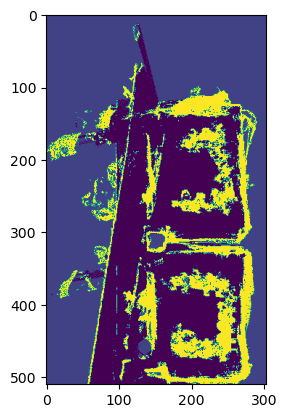

In [8]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pdb
from scipy.signal import correlate
import yaml
from PIL import Image

fixed_size = (128, 128)
dataset_dir = '/ibex/user/alham0a/localization_project/data/datasets/umgloc_dataset/'
lines = ['b9l4_2classes_2']
for line in lines:
    data_name = line.split(',')[0]  # get the trajectory file name (without extension)

    df = pd.read_csv(dataset_dir + data_name + '.csv')
    with open(dataset_dir + data_name + '.yaml') as f:
        meta = yaml.safe_load(f)
        print(meta)
    
    img = np.array(Image.open(meta['image']))    # [0,1]
    img = (255 - img) / 255 # ROS convention occ=1 white (>occ_thresh), free=0 (<free_thresh) black 
    origin = np.array(meta['origin'])
    plt.imshow(img)